# Test: Correctness Evaluation of Annotat3d Image Processing Operations

This notebook implements bitwise comparisons between ANnotat3d custum operations and well stablished open frameworks for image processing. 

## Import libraries

Assures that the harpia module has already been compiled with cython, before (command: python3 setup.py)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

#morphology functions
import harpia
from skimage import morphology
import harpia.morphology.operations_binary as harpia_binary
import harpia.morphology.operations_grayscale as harpia_grayscale

#filters functions
from skimage.filters import prewitt,sobel,gaussian,unsharp_mask
from skimage.restoration import denoise_nl_means #non-local-mean
from skimage import feature #canny
from skimage.filters.rank import mean,median


from scipy import ndimage
import harpia.filters.filtersChunked as filtersChunked
from harpia.filters import filters



In [2]:
import harpia
print(harpia.__file__) #assert it is importing the local compilation of harpia package

/home/ricardo.grangeiro/miniconda3/envs/dev/lib/python3.9/site-packages/harpia/__init__.cpython-39-x86_64-linux-gnu.so


## Save path

In [3]:
save = True
current_dir = os.getcwd()
results_dir = os.path.join(current_dir, "results_scikit")

import os
notebook_name = "test_correctness_report_scikit"
output_dir = f"{notebook_name}_plots"
os.makedirs(output_dir, exist_ok=True)
print(f"Plots will be saved to: {output_dir}")

Plots will be saved to: test_correctness_report_scikit_plots


## Framework

In [4]:
def custum_line_kernel3D():
    kernel_2d = np.array([[1, 0, 0], [1, 0, 0], [1, 0, 0]], dtype=np.int32)
    # Stack the 2D kernel to form a 3D kernel (3 layers)
    kernel_3d = np.stack([kernel_2d, kernel_2d, kernel_2d])
    return kernel_3d

In [5]:
'''
def custum_kernel3D():
    kernel_2d = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.int32)
    # Stack the 2D kernel to form a 3D kernel (3 layers)
    kernel_3d = np.stack([kernel_2d, kernel_2d, kernel_2d])
    return kernel_3d
'''
def custum_kernel3D(size=1):
    """
    Create a cubic 3D kernel for erosion, where `size` is the erosion radius.

    Parameters:
    - size (int): Number of pixels to erode from each side. 
                  The resulting kernel will be of shape (2*size + 1)^3.

    Returns:
    - numpy.ndarray: A 3D structuring element for erosion.
    """
    kernel_shape = (2 * size + 1, 2 * size + 1, 2 * size + 1)
    return np.ones(kernel_shape, dtype=np.int32)

In [6]:
def custum_kernel2D():
    kernel = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.int32)
    kernel = kernel.reshape(1, kernel.shape[0], kernel.shape[1])
    return kernel

In [7]:
def load_image(path, xsize, ysize, zsize, dtype, dtype_out):
    img = np.fromfile(path, dtype=dtype)
    img = img.reshape((zsize, ysize, xsize))
    img = img.astype(dtype = dtype_out)
    return img

In [8]:
# Function to compare the results
def show_results_diff(result_custum, original_image=None, plot=False, operation = "", framework = "", 
                 slice_num = 0, figsize=(18, 6), save_path=None):  
    fontsize = 18
    # Perform bitwise comparison
    bitwise_diff = np.abs(original_image.astype(np.int32) - result_custum.astype(np.int32))
    
    if(plot):
        if(len(original_image.shape)==3):
            original_slice = original_image[slice_num,:,:]
            slice_groudtruth = result_groudtruth[slice_num,:,:]
            slice_custum = result_custum[slice_num,:,:]
            slice_diff = bitwise_diff[slice_num,:,:]
        # Visual comparison
        plt.figure(figsize=figsize)

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(original_slice, cmap='gray')
        plt.title("Original Image", fontsize = fontsize)
        plt.axis('off')

        # Custum result
        plt.subplot(1, 3, 2)
        plt.imshow(slice_custum, cmap='gray')
        plt.title(f"Annotat3d {operation}", fontsize = fontsize)
        plt.axis('off')

        # Bitwise difference
        plt.subplot(1, 3, 3)
        plt.imshow(slice_diff, cmap='hot')
        plt.title("Bitwise Difference", fontsize = fontsize)
        plt.axis('off')

        plt.tight_layout()
        
        # Save the plot if a save path is provided
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
        
        plt.show()
    
    return 

In [9]:
def show_results(result_custum, original_image=None, plot=False, operation = "", framework = "", 
                 slice_num = 0, figsize=(18, 6), save_path=None):  
    fontsize = 18
    # Perform bitwise comparison
    bitwise_diff = np.abs(original_image.astype(np.int32) - result_custum.astype(np.int32))
    
    if(plot):
        if(len(original_image.shape)==3):
            original_slice = original_image[slice_num,:,:]
            slice_groudtruth = result_groudtruth[slice_num,:,:]
            slice_custum = result_custum[slice_num,:,:]
            slice_diff = bitwise_diff[slice_num,:,:]
        # Visual comparison
        plt.figure(figsize=figsize)

        # Original image
        plt.subplot(1, 2, 1)
        plt.imshow(original_slice, cmap='gray')
        plt.title("Original Image", fontsize = fontsize)
        plt.axis('off')
        
        # Custum result
        plt.subplot(1, 2, 2)
        plt.imshow(slice_custum, cmap='gray')
        plt.title(f"Annotat3d {operation}", fontsize = fontsize)
        plt.axis('off')

        plt.tight_layout()
        
        # Save the plot if a save path is provided
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
        
        plt.show()
    
    return 

In [10]:
# Function to compare the results
def compare_results(result_custum, result_groudtruth, original_image=None, plot=False, operation="", framework="", 
                    slice_num=0, figsize=(18, 6), save_path=None):  
    fontsize = 18
    # Perform bitwise comparison
    bitwise_diff = np.abs(result_groudtruth.astype(np.int32) - result_custum.astype(np.int32))
    
    if plot:
        if len(original_image.shape) == 3:
            original_slice = original_image[slice_num, :, :]
            slice_groudtruth = result_groudtruth[slice_num, :, :]
            slice_custum = result_custum[slice_num, :, :]
        
        # Visual comparison without bitwise difference
        plt.figure(figsize=figsize)

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(original_slice, cmap='gray')
        plt.title("Original Image", fontsize=fontsize)
        plt.axis('off')

        # Ground truth result
        plt.subplot(1, 3, 2)
        plt.imshow(slice_groudtruth, cmap='gray')
        plt.title(f"{framework} {operation}", fontsize=fontsize)
        plt.axis('off')

        # Custom result
        plt.subplot(1, 3, 3)
        plt.imshow(slice_custum, cmap='gray')
        plt.title(f"Annotat3d {operation}", fontsize=fontsize)
        plt.axis('off')

        plt.tight_layout()
        
        # Save the plot if a save path is provided
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
        
        plt.show()
    
    # Return pixel-wise statistics
    total_pixels = np.prod(original_image.shape)
    num_diff_pixels = np.count_nonzero(bitwise_diff)
    print(f"Total pixels: {total_pixels}")
    print(f"Different pixels: {num_diff_pixels}")
    print(f"Accuracy: {((total_pixels - num_diff_pixels) / total_pixels) * 100:.2f}%")
    print(f"Difference value: {bitwise_diff.mean():.2f} ± {bitwise_diff.std():.2f}")
    
    return


In [11]:
def compare_results_filters(result_custum, result_groudtruth, original_image=None, plot=False, operation="", framework="", 
                    slice_num=0, figsize=(18, 6), save_path=None):
    fontsize = 18
    eps = 1e-8  # to prevent division by zero

    # Relative error in percentage
    relative_error = 100.0 * np.abs(result_groudtruth - result_custum) / (np.abs(result_groudtruth) + eps)

    if plot and original_image is not None and len(original_image.shape) == 3:
        original_slice = original_image[slice_num, :, :]
        slice_groudtruth = result_groudtruth[slice_num, :, :]
        slice_custum = result_custum[slice_num, :, :]

        plt.figure(figsize=figsize)

        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(original_slice, cmap='gray')
        plt.title("Original Image", fontsize=fontsize)
        plt.axis('off')

        # Ground truth result
        plt.subplot(1, 3, 2)
        plt.imshow(slice_groudtruth, cmap='gray')
        plt.title(f"{framework} {operation}", fontsize=fontsize)
        plt.axis('off')

        # Custom result
        plt.subplot(1, 3, 3)
        plt.imshow(slice_custum, cmap='gray')
        plt.title(f"Annotat3d {operation}", fontsize=fontsize)
        plt.axis('off')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
        plt.show()

    # Filter out invalid values (e.g., inf or nan)
    rel_err_flat = relative_error[np.isfinite(relative_error)]

    # Compute percentage-based statistics
    mean_rel_error = rel_err_flat.mean()
    std_rel_error = rel_err_flat.std()

    print(f"Mean Relative Error: {mean_rel_error:.2f}%")
    print(f"Std Dev of Relative Error: {std_rel_error:.2f}%")



## Grayscale input

In [12]:
# original img
xsize = 190
ysize = 207
zsize_original = 100
zsize = 100
image = load_image("../../example_images/crua_A_190x207x100_16b.raw", xsize, ysize, zsize_original,'uint16', 'float32')
image = image[:zsize,:,:] #reduce size
image_slice = image[0,:,:]
image_slice3D = np.expand_dims(image_slice, axis=-1).reshape((1, ysize, xsize))


In [13]:
'''
# original img
xsize = 1540
ysize = 1540
zsize_original = 1000
zsize = 1000
image = load_image("/ibira/lnls/labs/tepui/home/egon.borges/workshop/Recon_fdk__tomo_z1_930_z1z2_1000_esp_1264_expt_1s_000_1540x1540x1000_float32.raw", xsize, ysize, zsize_original,'float32', 'float32')
image = image[:zsize,:,:] #reduce size
image_slice = image[0,:,:]
image_slice3D = np.expand_dims(image_slice, axis=-1).reshape((1, ysize, xsize))
'''

'\n# original img\nxsize = 1540\nysize = 1540\nzsize_original = 1000\nzsize = 1000\nimage = load_image("/ibira/lnls/labs/tepui/home/egon.borges/workshop/Recon_fdk__tomo_z1_930_z1z2_1000_esp_1264_expt_1s_000_1540x1540x1000_float32.raw", xsize, ysize, zsize_original,\'float32\', \'float32\')\nimage = image[:zsize,:,:] #reduce size\nimage_slice = image[0,:,:]\nimage_slice3D = np.expand_dims(image_slice, axis=-1).reshape((1, ysize, xsize))\n'

## Filters 2D

### Sobel

2d variant


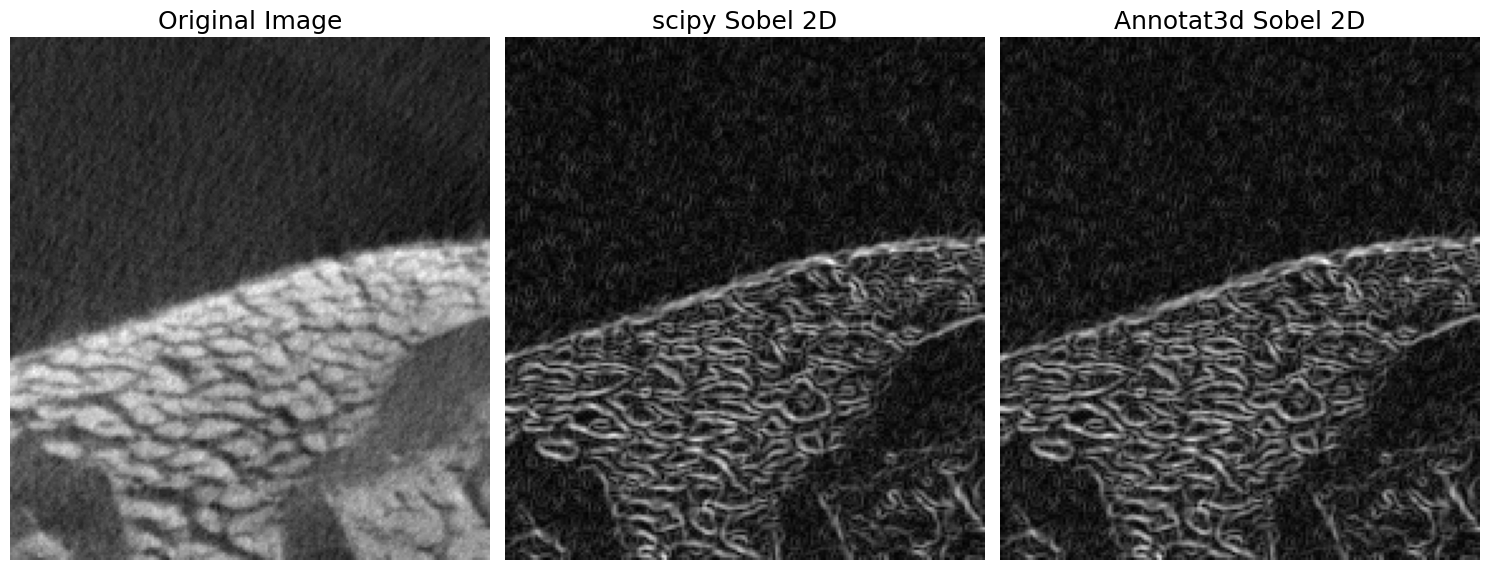

Mean Relative Error: 0.44%
Std Dev of Relative Error: 7.86%


In [14]:
sobel_h = ndimage.sobel(image_slice, 0)  # horizontal gradient
sobel_v = ndimage.sobel(image_slice, 1)  # vertical gradient
result_groudtruth= np.sqrt(sobel_h**2 + sobel_v**2)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))
out = filtersChunked.sobelFilter(image_slice3D.astype(np.float32),gpuMemory=0.2,verbose=1,type3d=0)

compare_results_filters(out, result_groudtruth3D, image_slice3D, plot=True, operation = "Sobel 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/sobel_2D.png")

### Prewitt

2d variant


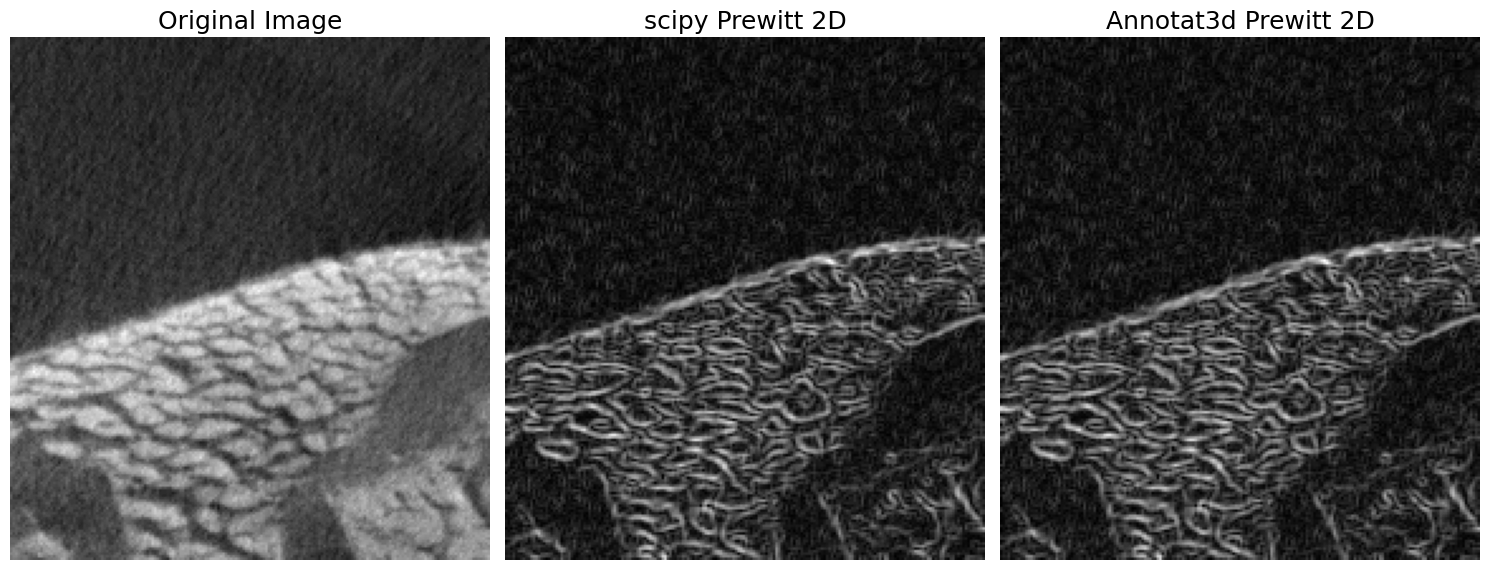

Mean Relative Error: 0.51%
Std Dev of Relative Error: 8.02%


In [15]:
sobel_h = ndimage.prewitt(image_slice, 0)  # horizontal gradient
sobel_v = ndimage.prewitt(image_slice, 1)  # vertical gradient
result_groudtruth= np.sqrt(sobel_h**2 + sobel_v**2)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))
out = filtersChunked.prewittFilter(image_slice3D,type3d=0)

compare_results_filters(out, result_groudtruth3D, image_slice3D, plot=True, operation = "Prewitt 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/prewitt_2D.png")

### Unsharp Mask

2d variant


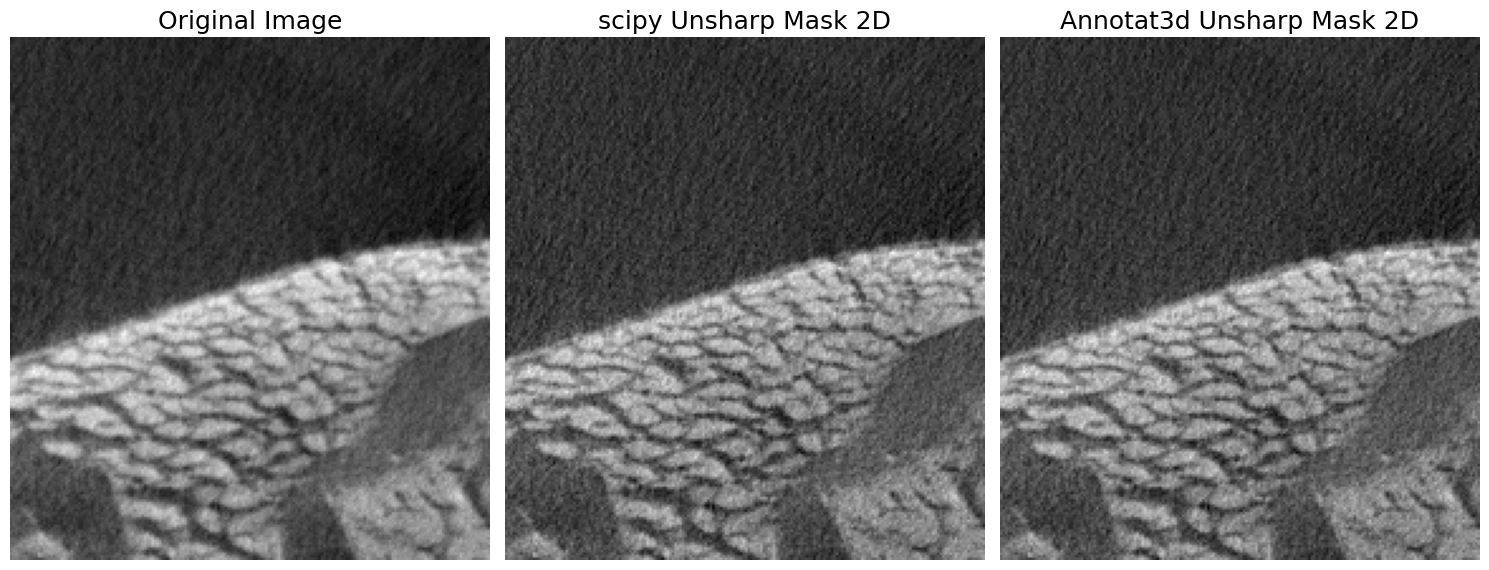

Mean Relative Error: 0.02%
Std Dev of Relative Error: 0.03%


In [16]:
result_groudtruth = unsharp_mask(image_slice,1,1,preserve_range=True)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))
out = filtersChunked.unsharpMaskFilter(image_slice3D)

compare_results_filters(out, result_groudtruth3D, image_slice3D, plot=True, operation = "Unsharp Mask 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/unsharp_mask_2D.png")

### Gaussian

2d variant


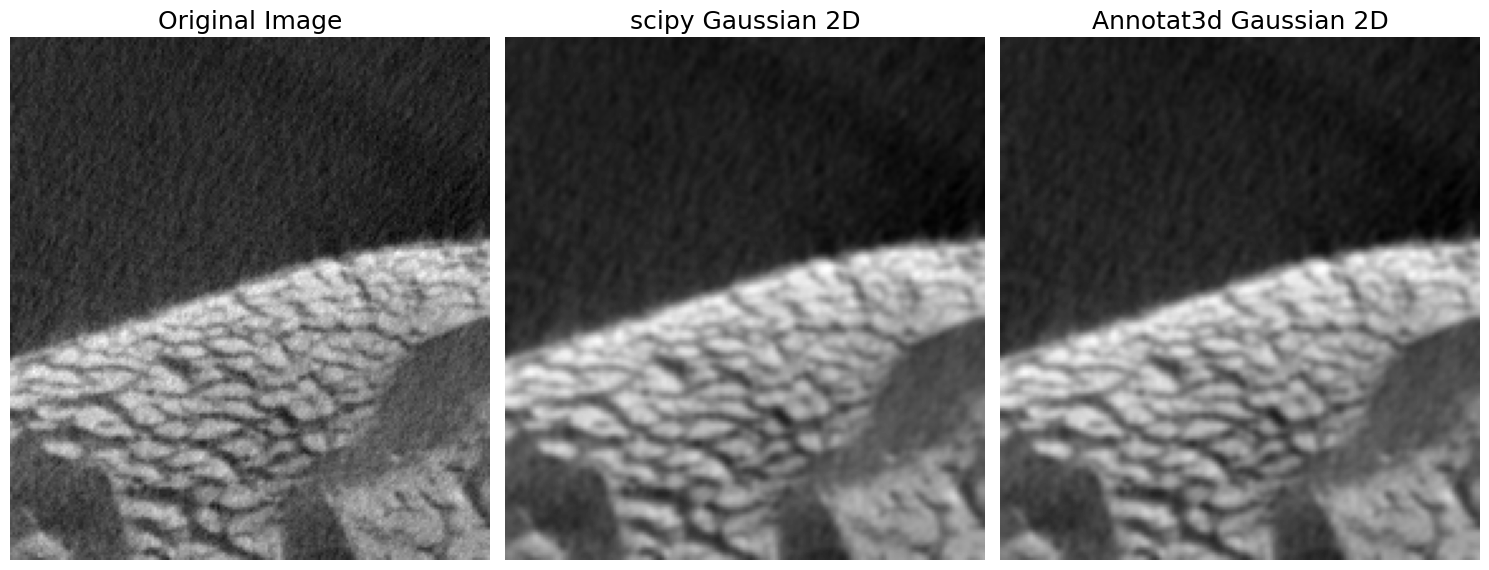

Mean Relative Error: 0.02%
Std Dev of Relative Error: 0.03%


In [17]:
result_groudtruth = gaussian(image_slice,1,mode='reflect',preserve_range=True)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))
out = filtersChunked.gaussianFilter(image_slice3D)

compare_results_filters(out, result_groudtruth3D, image_slice3D, plot=True, operation = "Gaussian 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/gaussian_2D.png")

### Median

/home/ricardo.grangeiro/miniconda3/envs/dev/lib/python3.9/site-packages/skimage/filters/rank/generic.py:268: UserWarning: Bad rank filter performance is expected due to a large number of bins (40275), equivalent to an approximate bitdepth of 15.3.
  image, footprint, out, mask, n_bins = _preprocess_input(image, footprint,


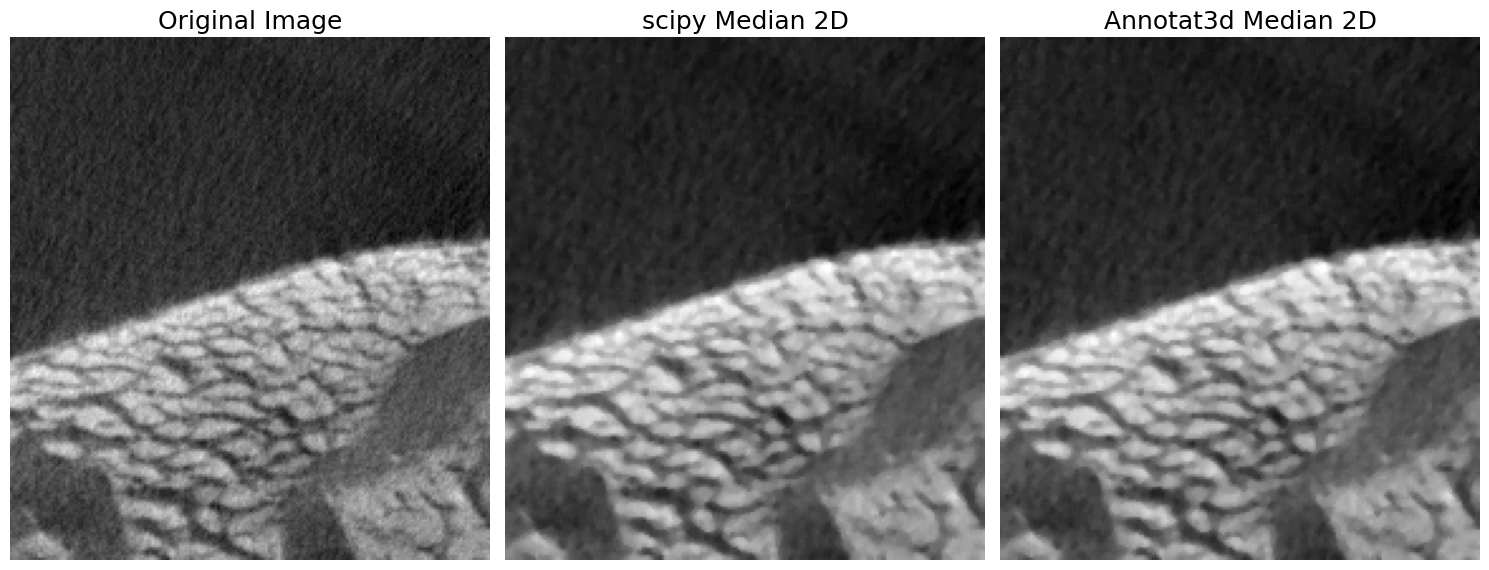

Mean Relative Error: 0.00%
Std Dev of Relative Error: 0.07%


In [18]:
kernel = np.ones((3,3))
d = np.ones((3,3))
result_groudtruth = median(image_slice3D[0].astype(np.uint16),d)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))


result_custum = filters.median(hostImage=image_slice3D,nx=3,ny=3,nz=1)

compare_results_filters(result_custum, result_groudtruth3D, image_slice3D, plot=True, operation = "Median 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/median_2D.png")

### Mean

2d variant


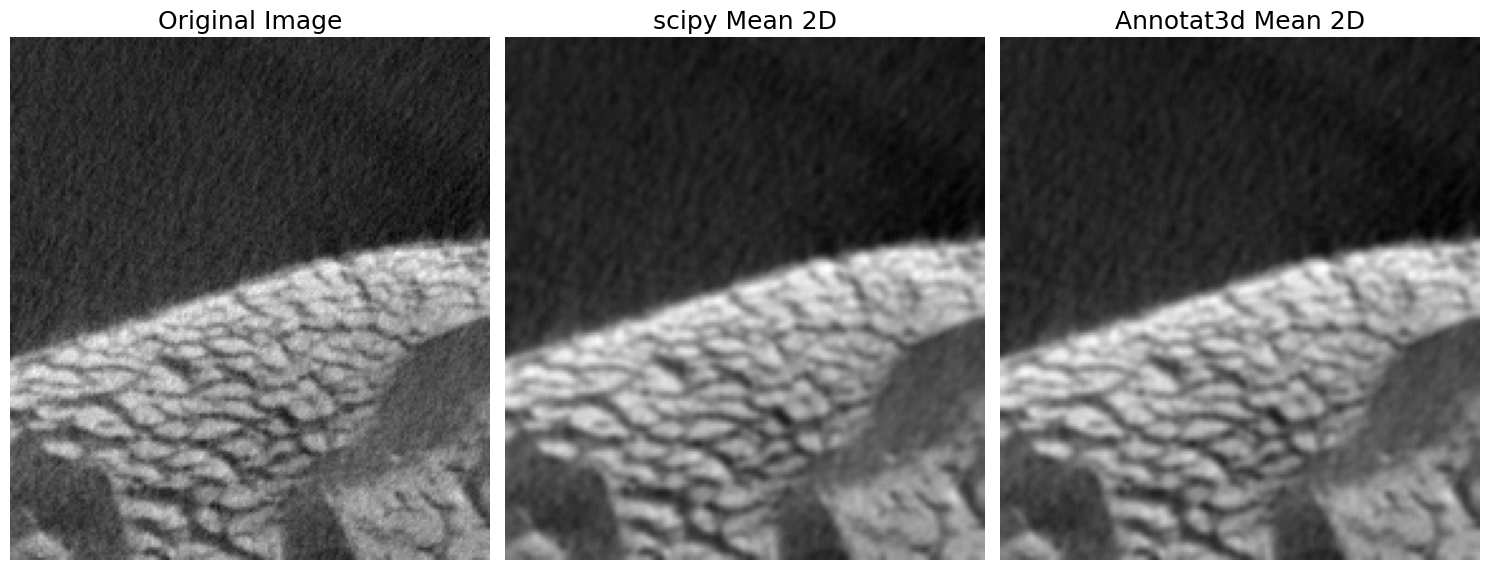

Mean Relative Error: 0.00%
Std Dev of Relative Error: 0.03%


In [19]:

kernel = np.ones((3,3))
d = np.ones((3,3))
result_groudtruth = mean(image_slice3D[0].astype(np.uint16),d)
result_groudtruth3D = np.expand_dims(result_groudtruth, axis=-1).reshape((1, ysize, xsize))
result_custum = filtersChunked.meanFilter(hostImage=image_slice3D, windowSize=3,type3d=1)

compare_results_filters(result_custum, result_groudtruth3D, image_slice3D, plot=True, operation = "Mean 2D", framework="scipy", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/mean_2D.png")

### Non-local Means

### Canny

## Morphology grayscale operations in 3D 

### Erosion

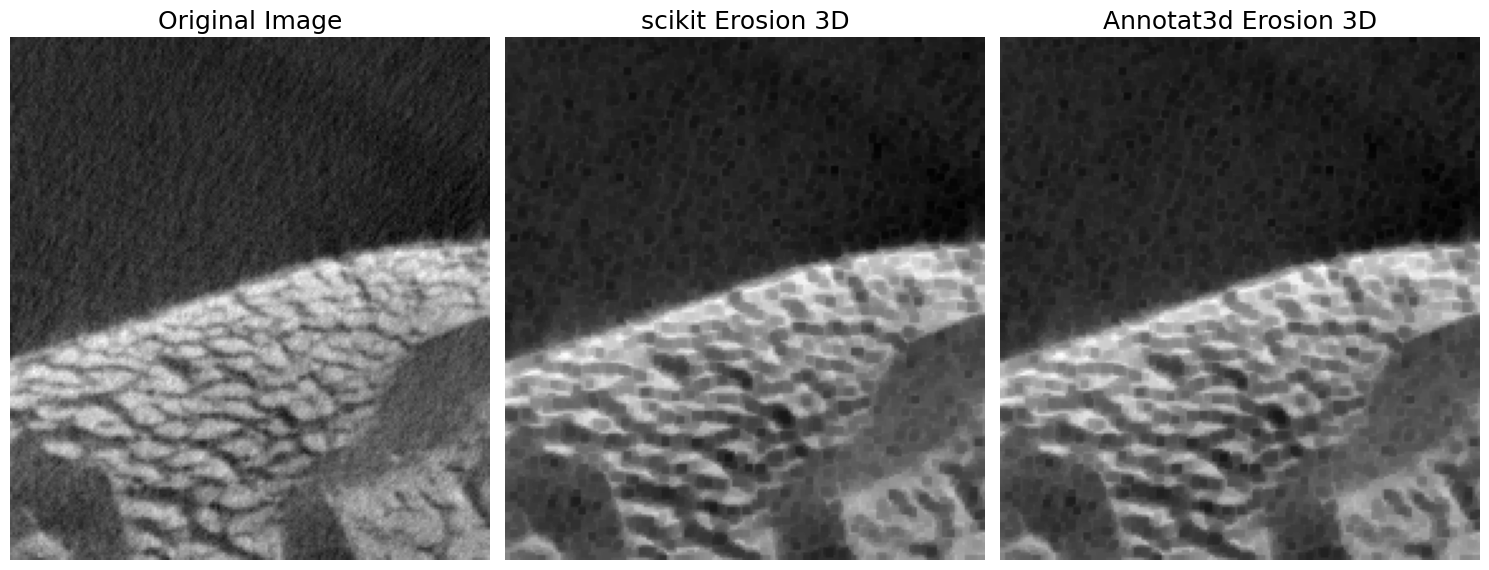

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [20]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_grayscale.erosion_grayscale(image, kernel, gpuMemory = 0.01)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.erosion(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "Erosion 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_erosion.png")

### Dilation 

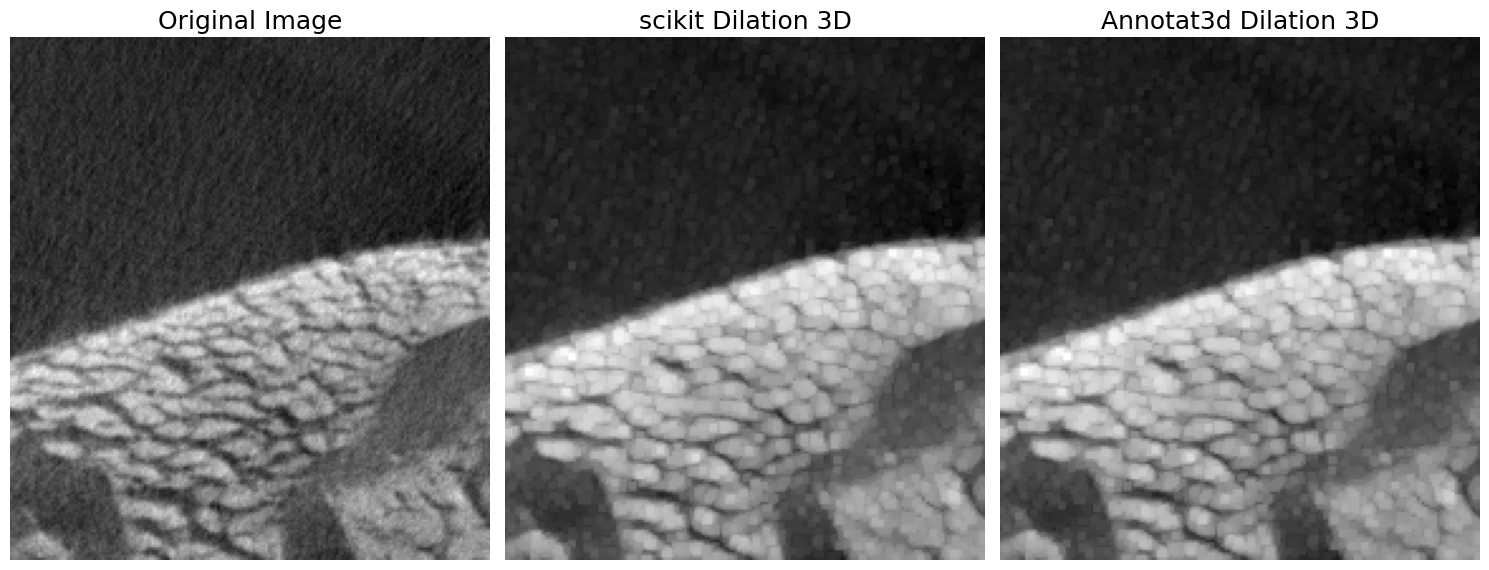

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [21]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_grayscale.dilation_grayscale(image, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.dilation(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "Dilation 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_dilation.png")

### Opening 

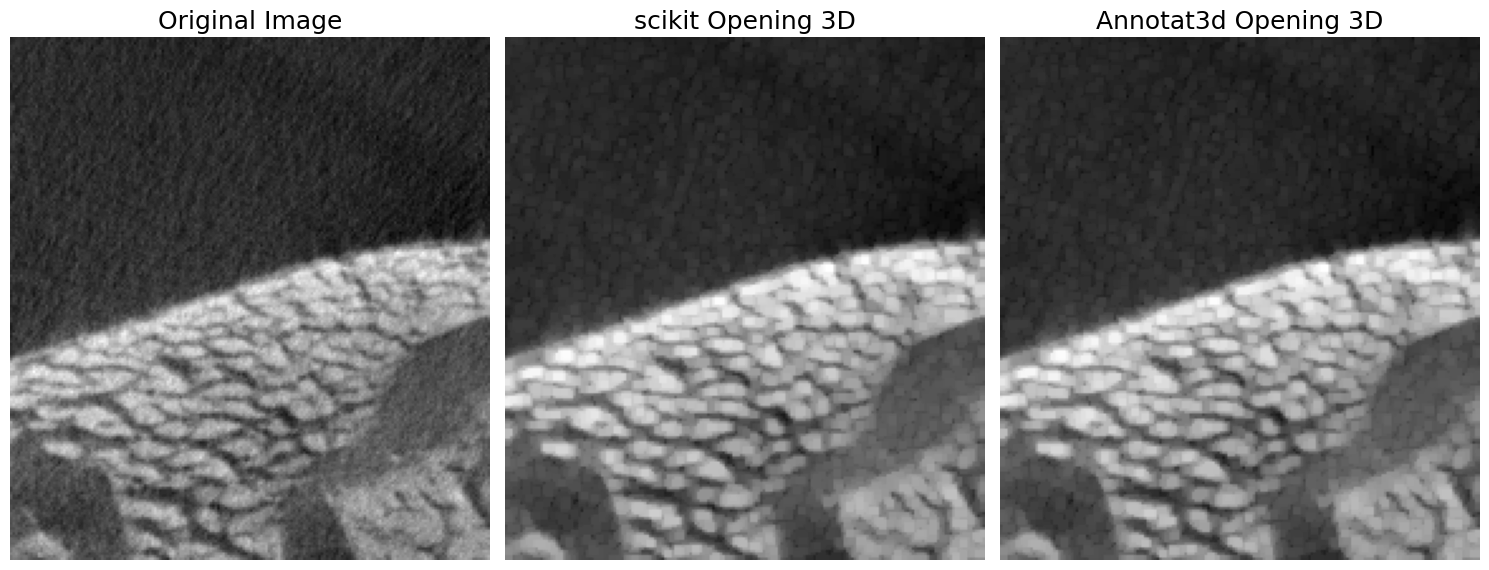

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [22]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_grayscale.opening_grayscale(image, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.opening(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "Opening 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_opening.png")

### Closing

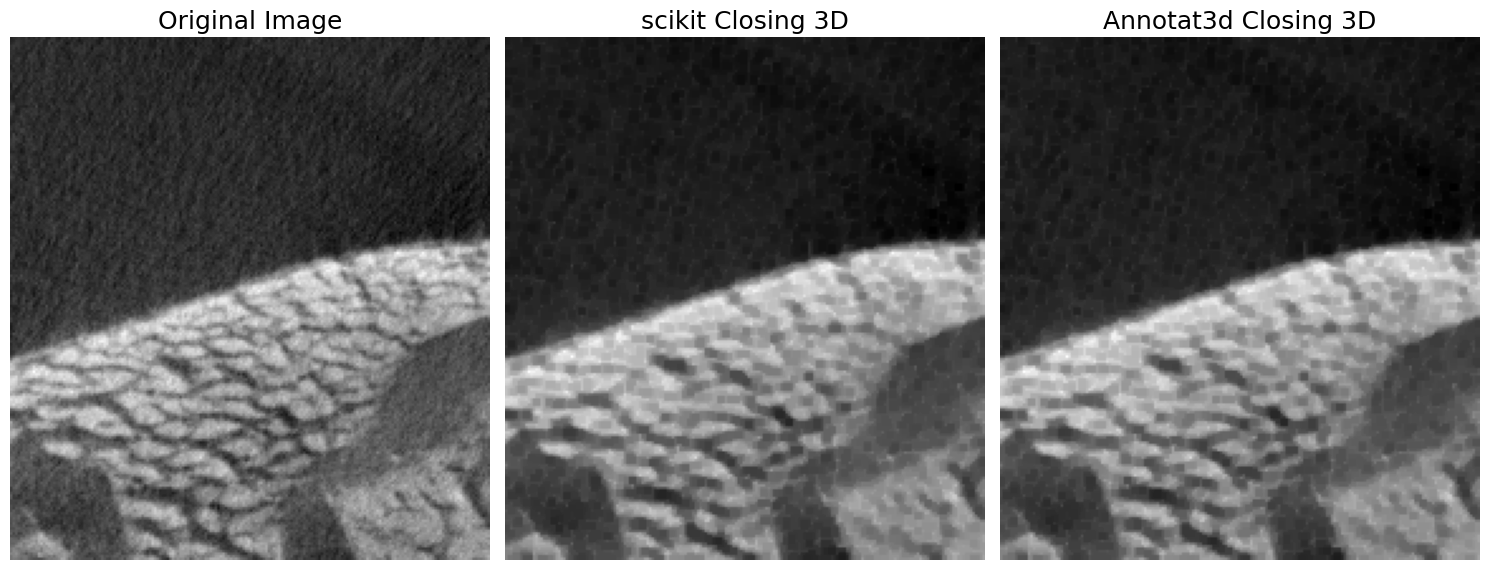

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [23]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_grayscale.closing_grayscale(image, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.closing(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "Closing 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_closing.png")

### Reconstruction

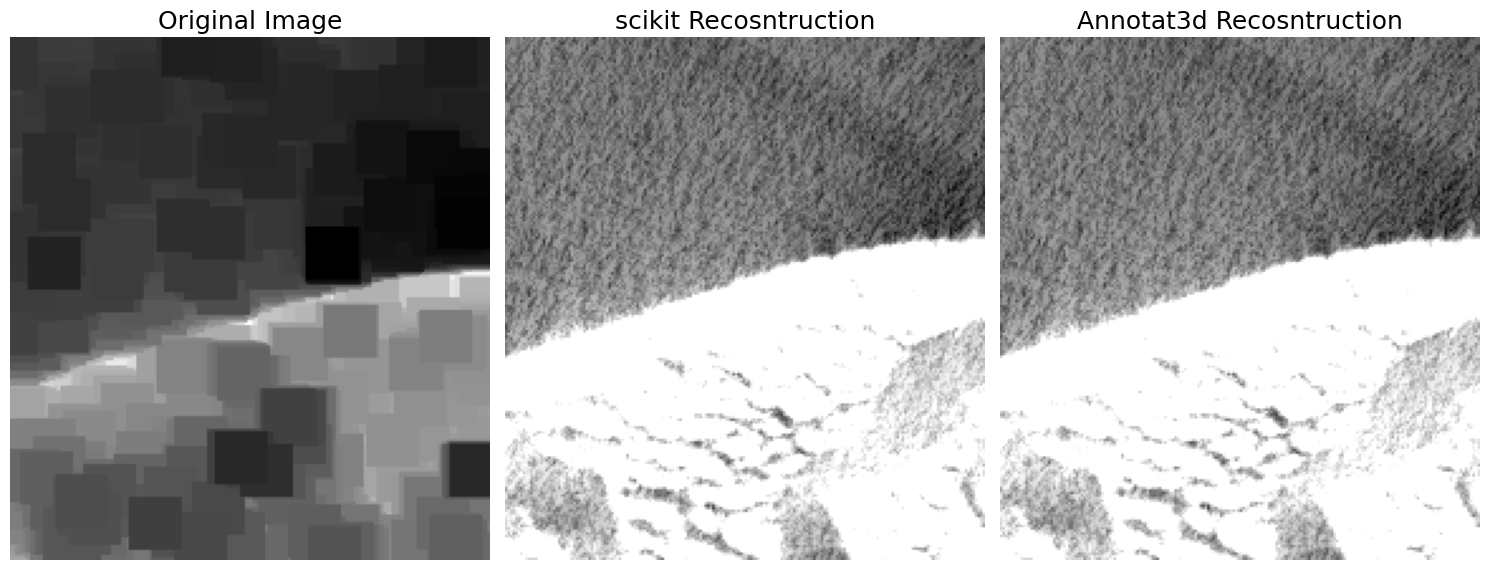

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [24]:
#Custum operation
kernel = custum_kernel3D()
marker = image
for i in range(10):
    marker = harpia_grayscale.erosion_grayscale(marker, kernel)
result_custum = harpia_grayscale.reconstruction_grayscale(marker,image, "dilation")
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.reconstruction(marker,image, method='dilation')

compare_results(result_custum, result_groudtruth, marker, plot=True, operation = "Recosntruction", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_reconstruction_dilation.png")

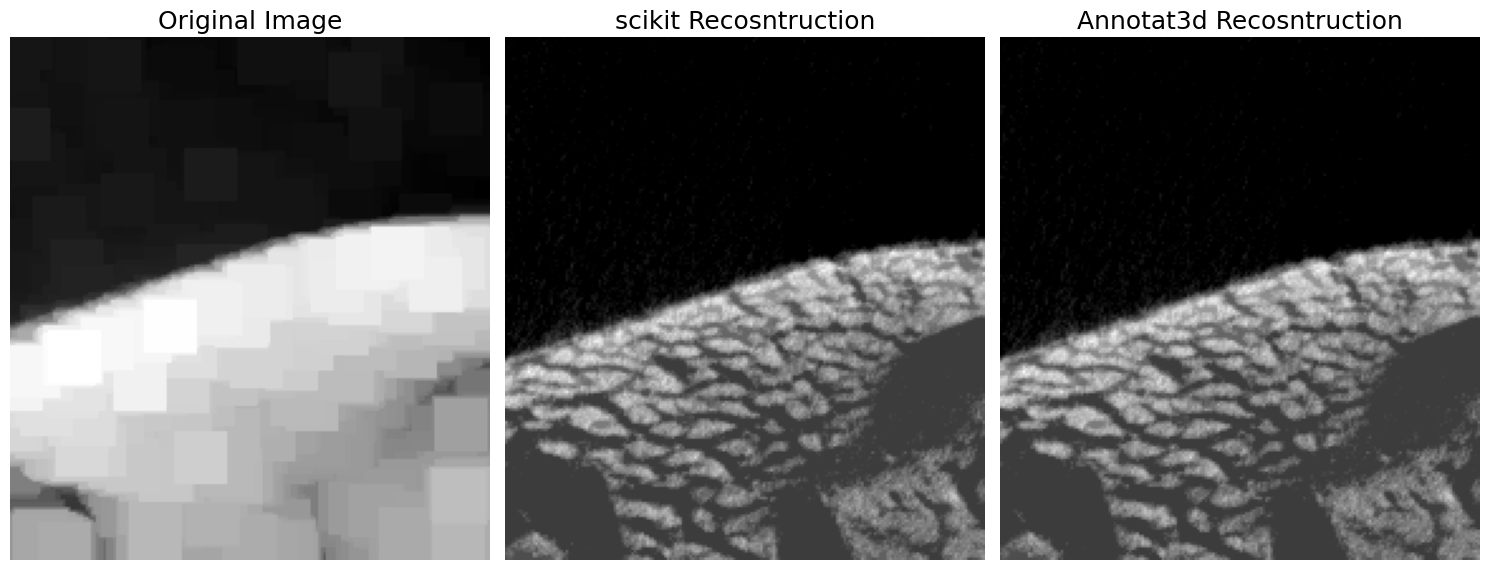

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [25]:
#Custum operation
kernel = custum_kernel3D()
marker = image
for i in range(10):
    marker = harpia_grayscale.dilation_grayscale(marker, kernel)
result_custum = harpia_grayscale.reconstruction_grayscale(marker,image, "erosion")
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.reconstruction(marker,image, method='erosion')

compare_results(result_custum, result_groudtruth, marker, plot=True, operation = "Recosntruction", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_reconstruction_erosion.png")

### Top hat (White tophat)

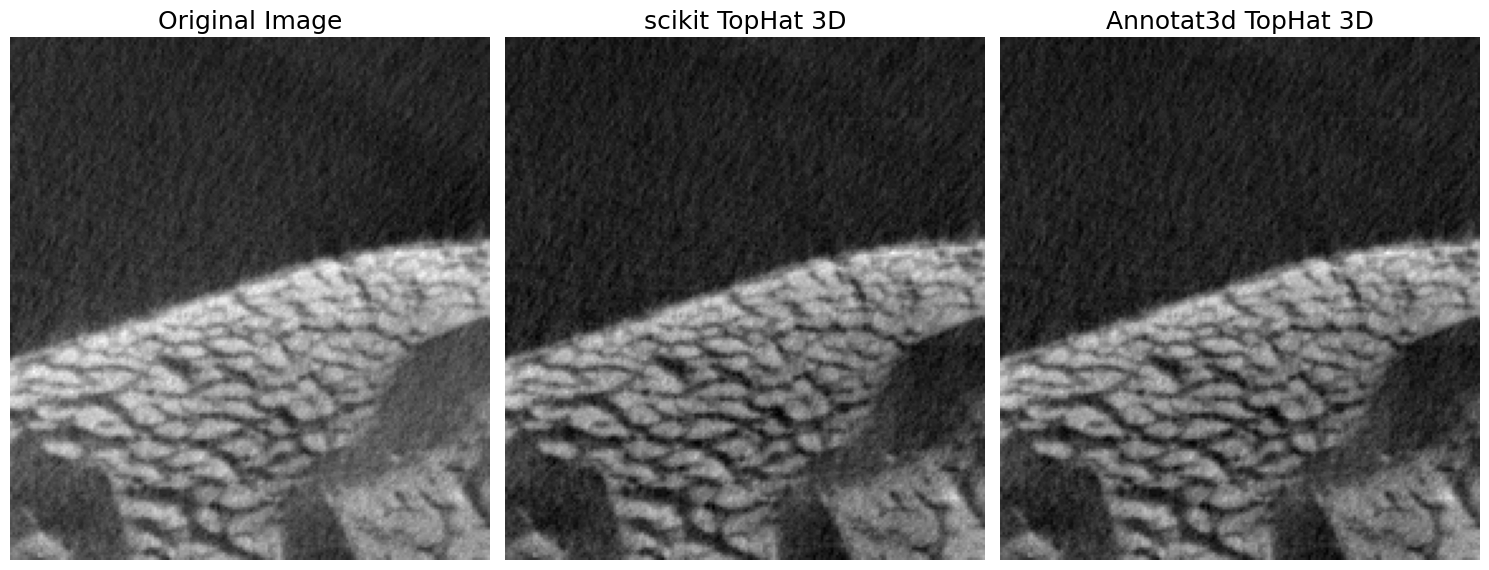

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [26]:
#Custum operation
kernel_size = 20
kernel = custum_kernel3D(kernel_size)
result_custum = harpia_grayscale.top_hat(image, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(2*kernel_size+1)
result_groudtruth = morphology.white_tophat(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "TopHat 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_tophat.png")

### Bottom hat (Black tophat)

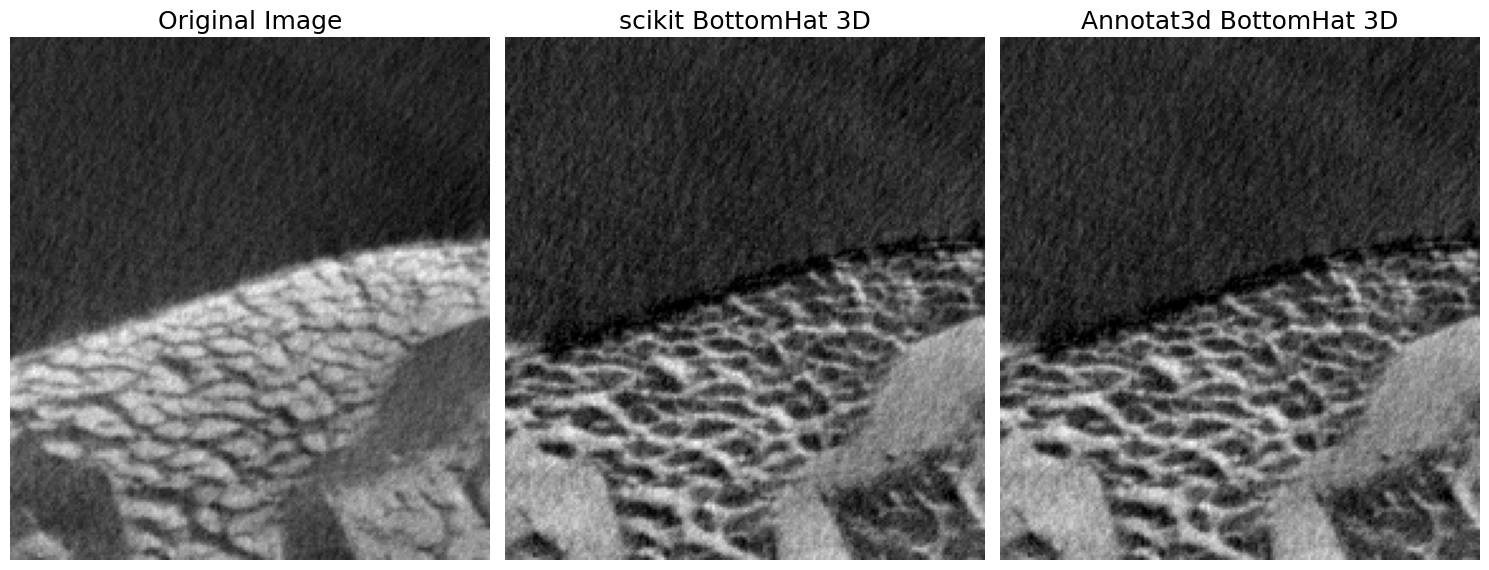

Total pixels: 3933000
Different pixels: 0
Accuracy: 100.00%
Difference value: 0.00 ± 0.00


In [27]:
#Custum operation
kernel_size = 20
kernel = custum_kernel3D(kernel_size)
result_custum = harpia_grayscale.bottom_hat(image, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(kernel_size*2+1)
result_groudtruth = morphology.black_tophat(image, selem)

compare_results(result_custum, result_groudtruth, image, plot=True, operation = "BottomHat 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/grayscale_bottomhat.png")

### Top hat recosntruction (Avizo's inspired algorithm)

This algorithm was inspired by Avizo's implementation of the TopHat segemntation. We did not have acces to the Avizo's results to make a bitwise comparison.
(Ref: https://www.thermofisher.com/software-em-3d-vis/xtra-library/xtras/interactive-top-hat-by-reconstruction)

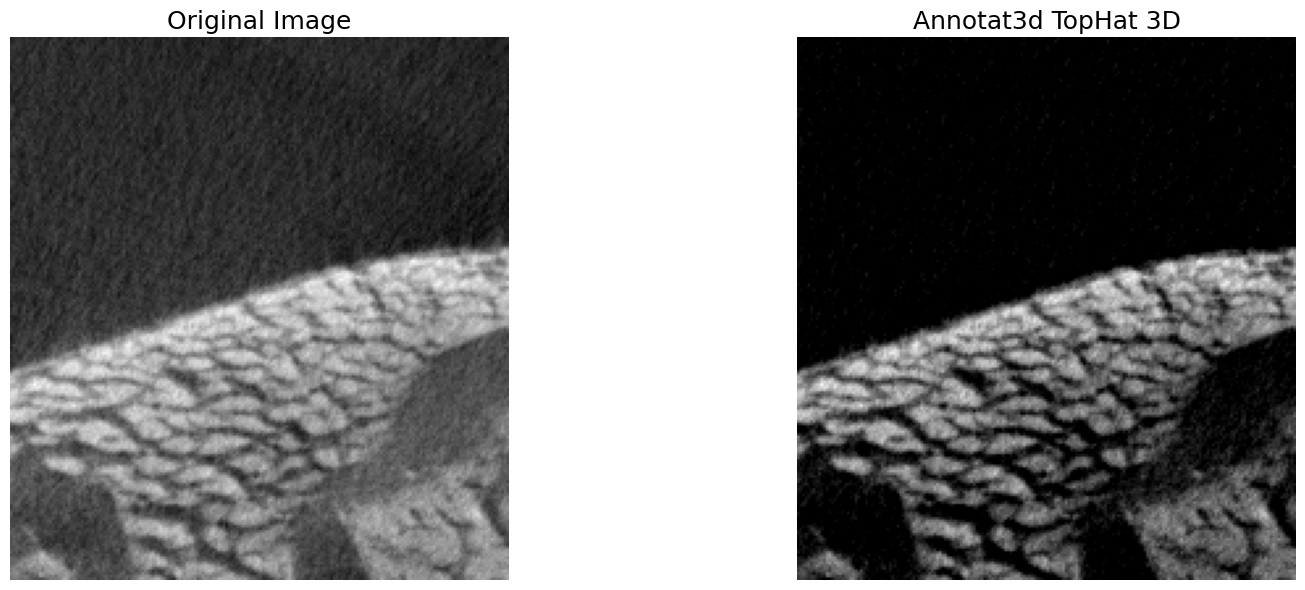

In [28]:
#Custum operation
kernel_size = 13

kernel = custum_kernel3D(kernel_size)
result_custum = harpia_grayscale.top_hat_reconstruction(image, kernel)
result_custum = result_custum.squeeze()

show_results(result_custum, image, plot=True, operation = "TopHat 3D", slice_num=0, save_path=f"{output_dir}/grayscale_tophat_reconstruction.png")

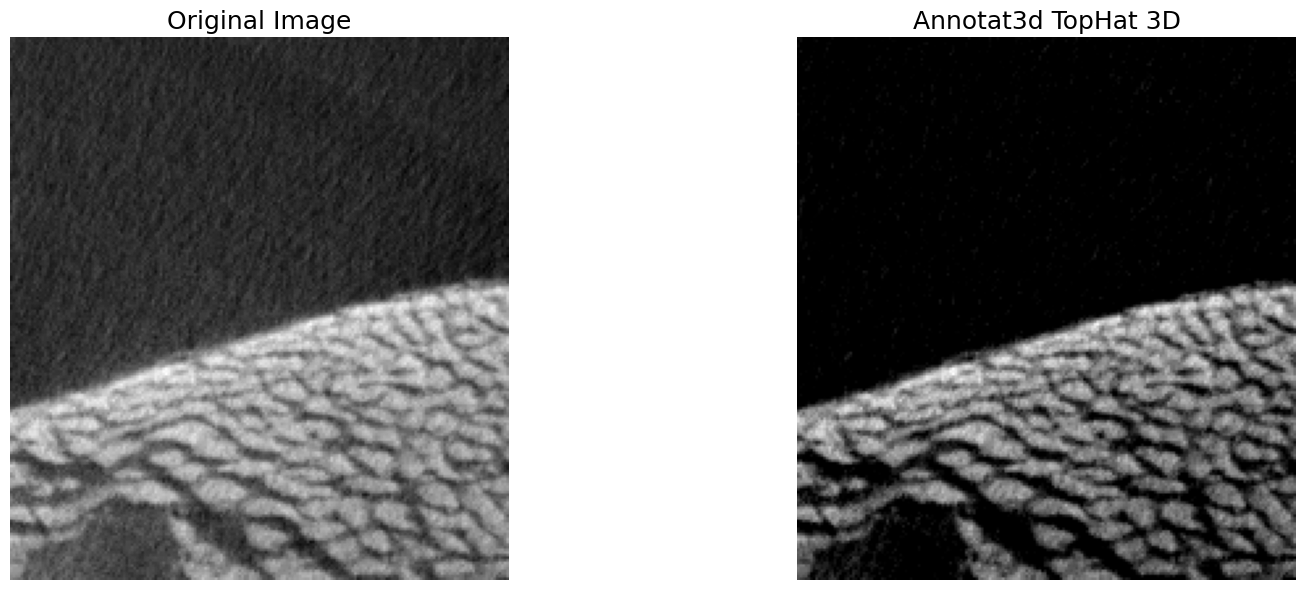

In [29]:
show_results(result_custum, image, plot=True, operation = "TopHat 3D", slice_num=50, save_path=f"{output_dir}/grayscale_tophat_reconstruction.png")

### Bottom hat recosntruction (Avizo's inspired algorithm)

This algorithm was inspired by Avizo's implementation of the TopHat segemntation. We did not have acces to the Avizo's results to make a bitwise comparison.
(Ref: https://www.thermofisher.com/software-em-3d-vis/xtra-library/xtras/interactive-top-hat-by-reconstruction)

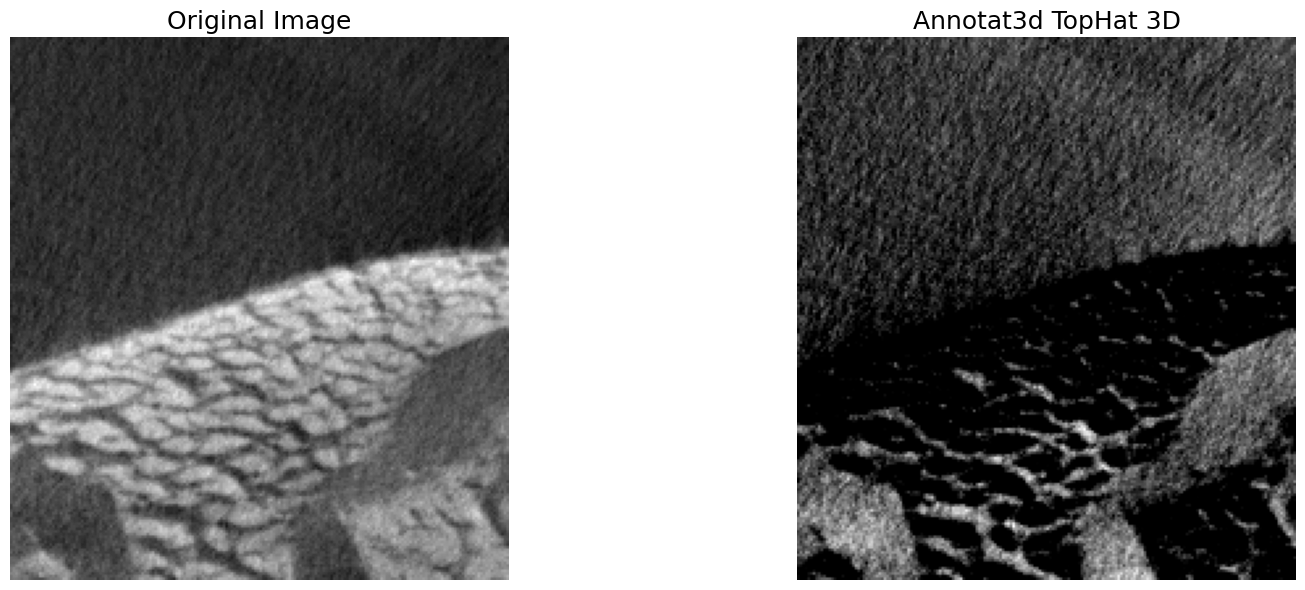

In [30]:
#Custum operation
kernel_size = 20
kernel = custum_kernel3D(kernel_size)
result_custum = harpia_grayscale.bottom_hat_reconstruction(image, kernel)
result_custum = result_custum.squeeze()

show_results(result_custum, image, plot=True, operation = "TopHat 3D", slice_num=0, save_path=f"{output_dir}/grayscale_bottomhat_reconstruction.png")

In [31]:
def process_image(data, plot=False):
    zsize, ysize, xsize = data.shape  # Get dimensions
    binarized_data = np.empty_like(data, dtype = 'int32')  # Prepare output array of same shape

    for slice_idx in range(zsize):
        slice_data = data[slice_idx, :, :]

        # Find min and max for the current slice
        min_val = slice_data.min()
        max_val = slice_data.max()

        # Compute threshold
        threshold = (max_val + min_val) // 2

        # Apply threshold to the slice to create a binary image
        binarized_slice = np.where(slice_data >= threshold, 1, 0)

        # Store the binarized slice in the output array
        binarized_data[slice_idx, :, :] = binarized_slice

    # Plot the first slice if plot flag is True
    if plot:
        plt.figure(figsize=(10, 4))

        # Plot original first slice
        plt.subplot(1, 2, 1)
        plt.imshow(data[0, :, :], cmap='gray')
        plt.title('Original First Slice')
        plt.axis('off')

        # Plot binarized first slice
        plt.subplot(1, 2, 2)
        plt.imshow(binarized_data[0, :, :], cmap='gray')
        plt.title('Binarized First Slice')
        plt.axis('off')

        plt.show()

    return binarized_data

## Binary input

In [32]:

# original img
xsize = 190
ysize = 207
zsize_original = 100
zsize = 100
image_binary = load_image("../../example_images/binary/crua_A_190x207x100_16b.raw", xsize, ysize, zsize_original,'uint16', 'int32')
image_binary = image_binary[:zsize,:,:] #reduce size
image_binary_slice = image_binary[0,:,:]
image_binary_slice3D = np.expand_dims(image_binary_slice, axis=-1).reshape((1, ysize, xsize))



FileNotFoundError: [Errno 2] No such file or directory: '../../example_images/binary/crua_A_190x207x100_16b.raw'

In [ ]:
'''
# original img
xsize = 1540
ysize = 1540
zsize_original = 1000
zsize = 1000
image_binary = load_image("/ibira/lnls/labs/tepui/home/egon.borges/workshop/Recon_fdk__tomo_z1_930_z1z2_1000_esp_1264_expt_1s_000_1540x1540x1000_float32.raw", xsize, ysize, zsize_original,'float32', 'float32')
image_binary = image_binary[:zsize,:,:] #reduce size
image_binary_slice = image_binary[0,:,:]
image_binary_slice3D = np.expand_dims(image_binary_slice, axis=-1).reshape((1, ysize, xsize))

'''

## Morphology binary operations in 3D 

### Erosion

In [ ]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_binary.erosion_binary(image_binary, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.erosion(image_binary, selem)

compare_results(result_custum, result_groudtruth, image_binary, plot=True, operation = "Erosion 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_erosion.png")

### Dilation 

In [ ]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_binary.dilation_binary(image_binary, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.dilation(image_binary, selem)

compare_results(result_custum, result_groudtruth, image_binary, plot=True, operation = "Dilation 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_dilation.png")

### Opening 

In [ ]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_binary.opening_binary(image_binary, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.opening(image_binary, selem)

compare_results(result_custum, result_groudtruth, image_binary, plot=True, operation = "Opening 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_opening.png")

### Closing

In [ ]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_binary.closing_binary(image_binary, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.closing(image_binary, selem)

compare_results(result_custum, result_groudtruth, image_binary, plot=True, operation = "Closing 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_closing.png")

### Reconstruction

In [ ]:
#Custum operation
kernel = custum_line_kernel3D()
marker = harpia_grayscale.erosion_grayscale(image_binary, kernel)

result_custum = harpia_binary.reconstruction_binary(marker,image_binary, "dilation")
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.reconstruction(marker, image_binary, method='dilation')

compare_results(result_custum, result_groudtruth, marker, plot=True, operation = "recosntruction 3D", 
                framework="scikit", slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_reconstruction_dilation.png")

### Smoothing

In [ ]:
#Custum operation
kernel = custum_kernel3D()
result_custum = harpia_binary.smooth_binary(image_binary, kernel)
result_custum = result_custum.squeeze()

#Scikit-learn operation
selem = morphology.cube(3)
result_groudtruth = morphology.opening(image_binary, selem)
result_groudtruth = morphology.closing(result_groudtruth, selem)

compare_results(result_custum, result_groudtruth, image_binary, plot=True, operation = "Smoothing 3D", framework="scikit", 
                slice_num=0, figsize = (15,30), save_path=f"{output_dir}/binary_reconstruction_erosion.png")

### Fill Holes

In [ ]:
#Custum operation
result_custum = harpia_binary.fill_holes(image_binary)
result_custum = result_custum.squeeze()

show_results_diff(result_custum, image_binary, plot=True, operation = f"{output_dir}/fill holes 3D", slice_num=3, figsize = (15,30), save_path="binary_fill_holes3.png")